# Depth Anything V1: GTX 1660 SUPER One-Epoch Fine-Tuning

## A balanced one-epoch notebook optimized for NVIDIA GeForce GTX 1660 SUPER

This notebook explains and demonstrates **monocular depth estimation** with **Depth Anything V1**. It is customized for the following computer:

| Component | Target system |
|---|---|
| System | Gigabyte H410M HD3P desktop |
| CPU | Intel Core i5-10400, 6 cores / 12 threads |
| RAM | 16 GiB |
| Discrete GPU | NVIDIA GeForce GTX 1660 SUPER, Turing TU116, typically 6 GiB VRAM |
| Operating system | Ubuntu 22.04.5 LTS, 64-bit, X11 |

The default experiment uses `ViT-S/14`, a `336×336` training resolution, micro-batch size `2`, two-step gradient accumulation, a frozen DINOv2 encoder, `128` training samples, `16` validation samples, and exactly **one epoch**. This profile uses the GTX 1660 SUPER more effectively while remaining conservative for its typical 6 GiB VRAM capacity.

The notebook covers:

- the difference between relative and metric depth;
- DINOv2 patch tokens and transformer features;
- the DPT reassembly and feature-fusion decoder;
- paired RGB-depth preprocessing and valid-pixel masks;
- inverse-depth targets;
- scale-and-shift-invariant alignment and loss;
- AbsRel, RMSE, and delta-one evaluation;
- baseline evaluation, one-epoch fine-tuning, checkpointing, and inference;
- practical GTX 1660 SUPER troubleshooting and teaching exercises.

> Run the cells in order. Download the required NYU Parquet files manually before execution. The first run still downloads the official repository and pretrained model weights unless they are already cached.

## 1. What is monocular depth estimation?

The input is one RGB image:

\[
I \in \mathbb{R}^{H\times W\times 3}
\]

The desired output is a dense map with one value for every pixel:

\[
D \in \mathbb{R}^{H\times W}
\]

A value at location \((u,v)\) describes the estimated distance or relative depth of the scene point projected onto that pixel.

The problem is **ill-posed**. A single two-dimensional image does not uniquely determine the three-dimensional scene that produced it. The model therefore learns statistical depth cues from data, including:

- relative object size;
- linear perspective and vanishing points;
- occlusion order;
- texture gradients;
- shadows and shading;
- height relative to the horizon;
- familiar object sizes;
- semantic knowledge, such as the typical shape of a room, road, person, or chair.

This is different from stereo depth or LiDAR. Stereo uses two viewpoints and triangulation. LiDAR directly measures travel time. Monocular depth infers geometry from visual evidence and learned priors.

## 2. Relative depth, inverse depth, and metric depth

These terms must not be mixed.

| Representation | Interpretation | Unit | Can it directly report meters? |
|---|---|---|---:|
| Relative depth | Preserves near/far structure up to an unknown transformation | Unitless | No |
| Relative inverse depth | Larger scores usually indicate nearer regions | Unitless | No |
| Metric depth | Estimated physical camera-to-surface distance | Usually meters | Yes, within calibration and domain limits |

Depth Anything V1 foundation checkpoints are primarily **relative-depth models**. Their raw values preserve useful scene structure, but their global scale and offset are not guaranteed to match meters.

In this notebook, the supervised target is inverse metric depth:

\[
T = \frac{1}{D_{metric}}
\]

For example:

| Metric depth | Inverse depth |
|---:|---:|
| 1 m | 1.000 |
| 2 m | 0.500 |
| 4 m | 0.250 |
| 8 m | 0.125 |

Inverse depth gives more numerical emphasis to nearby objects, where small distance changes are often important. During training and evaluation, the relative model prediction is aligned to the inverse-depth target with one scale and one shift per image.

> The alignment uses ground truth. It cannot be performed on an arbitrary new image that has no ground-truth depth. Therefore the final inference section reports relative inverse depth, not meters.

## 3. Depth Anything V1 architecture at a glance

The forward path is:

```text
RGB image
    ↓
Resize and ImageNet normalization
    ↓
Non-overlapping 14×14 patches
    ↓
DINOv2 Vision Transformer encoder
    ↓
Four intermediate token representations
    ↓
DPT token-to-feature reassembly
    ↓
Multi-scale feature fusion and upsampling
    ↓
One-channel positive relative-depth map
```

The architecture has two conceptual parts:

1. **DINOv2 encoder:** builds a rich semantic representation and connects distant image regions through self-attention.
2. **DPT decoder/head:** converts transformer tokens back into spatial feature maps, combines multiple semantic levels, and predicts a dense value for every pixel.

The central teaching idea is:

> DINOv2 learns what the image contains and how its regions relate; DPT transforms that multi-level knowledge into a dense per-pixel depth prediction.

## 4. DINOv2 encoder: from pixels to tokens

### 4.1 Patch embedding

The `vits14` encoder uses a patch size of `14×14`. With the notebook input size `336×336`:

\[
N_h = 336/14 = 24, \qquad N_w = 336/14 = 24
\]

Therefore the image becomes:

\[
N = N_hN_w = 24\times24 = 576 \text{ patch tokens}
\]

Each flattened patch is projected to an embedding vector. For ViT-S, the embedding dimension is `384`, so the patch-token tensor is approximately:

```text
[batch, 576, 384]
```

A class token is processed alongside the patch tokens. Depth Anything retains patch tokens for dense prediction and can also use information derived from the class token in its readout path.

### 4.2 Self-attention

Self-attention allows every token to exchange information with other tokens. A local patch on the floor can therefore use evidence from the walls, furniture, and horizon. In simplified form:

\[
\operatorname{Attention}(Q,K,V)=
\operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
\]

Earlier transformer blocks tend to retain more local appearance and boundary information. Deeper blocks encode stronger semantics and global context. The decoder uses four intermediate layers so that it does not have to choose between precise spatial detail and high-level understanding.

## 5. DPT decoder: from tokens to a dense depth map

Transformer output is a sequence. Depth prediction needs a two-dimensional map. DPT performs three main operations.

### 5.1 Reassemble tokens into spatial grids

The `196` patch tokens are reshaped from `[B, 196, 384]` to `[B, 384, 14, 14]`. The class-token readout is incorporated according to the implementation, and a `1×1` projection changes the number of channels.

For Depth Anything Small, the four projected channel counts are:

```text
48, 96, 192, 384
```

### 5.2 Build an artificial feature pyramid

All transformer features initially share the patch-grid resolution. DPT resamples them to different scales:

| Branch | Approximate input | Resampling operation | Approximate output at 336×336 input |
|---|---|---|---|
| 1 | `384×24×24` | 4× transposed convolution | `48×96×96` |
| 2 | `384×24×24` | 2× transposed convolution | `96×48×48` |
| 3 | `384×24×24` | Identity-scale projection | `192×24×24` |
| 4 | `384×24×24` | Strided convolution | `384×12×12` |

These are architectural teaching shapes. Exact internal tensors should always be confirmed from the checked-out implementation and runtime hooks.

### 5.3 Fuse deep semantics with shallow detail

Fusion starts at the deepest, lowest-resolution feature. It is refined, upsampled, and added to the next feature. The process repeats until a high-resolution representation is produced:

```text
12×12 → 24×24 → 48×48 → 96×96 → higher-resolution output
```

Deep features contribute object identity, layout, and global context. Shallower features contribute edges and local structure. The output convolutions reduce the channels to one, interpolate to the requested image size, and apply a non-negative output activation.

## 6. Model size and the selected GTX 1660 SUPER profile

| Encoder | Repository parameter count | Practical role |
|---|---:|---|
| ViT-S/14 | 24.8 M | Selected: best balance of resolution, speed, and VRAM |
| ViT-B/14 | 97.5 M | Possible at a smaller input and batch size, but slower |
| ViT-L/14 | 335.3 M | Not recommended for one-epoch training on 6 GiB VRAM |

The official inference example commonly uses a larger resolution such as `518`, with aspect-ratio preservation and dimensions adjusted to a multiple of `14`. Training requires more memory than inference because the decoder must retain values needed for backpropagation.

This notebook therefore selects:

| Setting | Value | Reason |
|---|---:|---|
| Encoder | `vits` | Keeps the one-epoch run fast and stable |
| Input | `336×336` | 24×24 tokens; better boundaries than the low-memory profile |
| Micro-batch | `2` | Designed for a typical 6 GiB GTX 1660 SUPER |
| Accumulation | `2` | Effective batch size 4 without doubling peak VRAM |
| Encoder training | Frozen | Saves activation memory and protects pretrained features |
| Train/validation samples | `128 / 16` | Enough iterations for a meaningful one-epoch demonstration |

`torch.compile` is intentionally disabled. Compilation overhead can dominate a run that lasts only one epoch, and it can increase memory use during graph compilation.

## 7. How the original Depth Anything training differs from this notebook

The original work scaled depth learning with a much larger data engine:

1. A teacher was built using roughly `1.5 million` labeled images.
2. The teacher generated pseudo-depth labels for more than `62 million` unlabeled images.
3. A student learned from labeled and pseudo-labeled data.
4. Strong perturbations made the student's input harder than the teacher's input, encouraging robustness instead of simple imitation.
5. Auxiliary semantic supervision helped preserve the rich priors of strong pretrained encoders.
6. Separate metric-depth fine-tuning used datasets such as NYU Depth V2 and KITTI.

This notebook does **not** reproduce that pretraining process. It starts from the released relative-depth checkpoint and demonstrates a small supervised adaptation on RGB-depth pairs.

## 8. One-time Ubuntu environment setup

### 8.1 Confirm the NVIDIA driver

Run this in a terminal before starting Jupyter:

```bash
nvidia-smi
```

The command should display the GTX 1660 SUPER and a working NVIDIA driver. If the GPU is missing, use Ubuntu's **Software & Updates → Additional Drivers** to install the recommended proprietary driver, then reboot.

### 8.2 Create an isolated Python 3.11 environment

Python `3.11` provides broad compatibility with the older Depth Anything V1 repository and current scientific packages:

```bash
conda create -n depthanything python=3.11 -y
conda activate depthanything
python -m pip install --upgrade pip

python -m pip install torch==2.12.1 torchvision==0.27.1 \
  --index-url https://download.pytorch.org/whl/cu126

python -m pip install \
  jupyterlab ipykernel datasets h5py matplotlib tqdm pillow \
  opencv-python huggingface_hub

python -m ipykernel install --user \
  --name depthanything \
  --display-name "Python (depthanything)"

jupyter lab
```

Select the kernel **Python (depthanything)** before running any code cell.

### 8.3 Why the CUDA 12.6 wheel is selected

The GTX 1660 SUPER is a Turing-generation GPU with compute capability `7.5`. The CUDA 12.6 PyTorch wheel is a conservative, broadly compatible choice for Ubuntu 22.04. The CUDA runtime is bundled with the PyTorch wheel; a separate system CUDA toolkit is not required for this notebook. The NVIDIA driver shown by `nvidia-smi` must still be new enough for that runtime.

If CUDA is unavailable after installation, first verify that Jupyter is using this exact kernel, then inspect `nvidia-smi` and update the recommended proprietary NVIDIA driver if necessary.

## 9. Download and pin the official repository

The repository is cloned next to this notebook and checked out at a fixed commit. Pinning the commit makes the notebook more reproducible than silently following future changes on the default branch.

Re-running the cell is safe: an existing repository is reused and reset only to the specified commit. Your own files should not be placed inside the cloned `Depth-Anything` directory.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_DIR = NOTEBOOK_DIR / "Depth-Anything"
REPO_COMMIT = "1d03336771fe09c5398ffdd211441e33941a97dc"

if not REPO_DIR.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "https://github.com/LiheYoung/Depth-Anything.git",
            str(REPO_DIR),
        ],
        check=True,
    )

subprocess.run(
    ["git", "-C", str(REPO_DIR), "fetch", "--depth", "1", "origin", REPO_COMMIT],
    check=True,
)
subprocess.run(
    ["git", "-C", str(REPO_DIR), "checkout", "--detach", REPO_COMMIT],
    check=True,
)
os.chdir(REPO_DIR)

print("Working directory:", Path.cwd())
print("Python executable:", sys.executable)
print("Pinned repository commit:", REPO_COMMIT)

Working directory: /home/amin/Desktop/depthanythingv1/Depth-Anything
Python executable: /home/amin/anaconda3/envs/hfds/bin/python
Pinned repository commit: 1d03336771fe09c5398ffdd211441e33941a97dc


From https://github.com/LiheYoung/Depth-Anything
 * branch            1d03336771fe09c5398ffdd211441e33941a97dc -> FETCH_HEAD
HEAD is now at 1d03336 Merge pull request #213 from 1ssb/patch-1


## 10. Imports, reproducibility, and hardware diagnostics

The next cell:

- fixes random seeds for a more repeatable teaching run;
- limits CPU thread counts so the laptop remains responsive;
- chooses CUDA automatically when available;
- prints GPU memory and compute capability;
- performs a small CUDA tensor test before the expensive model is loaded;
- falls back to CPU when CUDA is unavailable.

Deterministic equality is not guaranteed across every driver, CUDA, and PyTorch version, but fixed seeds remove a major source of accidental variation.

In [2]:
import io
import math
import os
import random
from contextlib import nullcontext
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageOps

# Reduce allocator fragmentation on a low-memory CUDA device.
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import ColorJitter
from torchvision.transforms import functional as TF
from tqdm.auto import tqdm

from depth_anything.dpt import DepthAnything

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

CPU_THREADS = min(8, os.cpu_count() or 1)
torch.set_num_threads(CPU_THREADS)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("PyTorch CUDA runtime:", torch.version.cuda)
print("Selected device:", DEVICE)
print("CPU threads:", CPU_THREADS)

if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    GPU_VRAM_GB = props.total_memory / 1024**3
    capability = torch.cuda.get_device_capability(0)
    architecture = f"sm_{capability[0]}{capability[1]}"
    print("GPU:", props.name)
    print(f"VRAM: {GPU_VRAM_GB:.2f} GiB")
    print("Compute capability:", capability)
    print("Expected architecture label:", architecture)
    print("Architectures compiled into this PyTorch build:", torch.cuda.get_arch_list())
    if architecture not in torch.cuda.get_arch_list():
        print(
            "WARNING: This PyTorch wheel does not list the GPU architecture. "
            "Install a PyTorch CUDA wheel that contains the detected GPU architecture."
        )
    test_tensor = torch.ones(8, device=DEVICE)
    print("CUDA tensor test:", float(test_tensor.sum()))
    del test_tensor
    torch.backends.cudnn.benchmark = True
else:
    GPU_VRAM_GB = 0.0
    print("WARNING: CUDA is unavailable. Training will continue on the CPU and will be slower.")
    print("Check nvidia-smi and confirm that the cu126 PyTorch wheel is installed.")

/home/amin/anaconda3/envs/hfds/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.6.0+cu124
PyTorch CUDA runtime: 12.4
Selected device: cuda:0
CPU threads: 8
GPU: NVIDIA GeForce GTX 1660 SUPER
VRAM: 5.61 GiB
Compute capability: (7, 5)
Expected architecture label: sm_75
Architectures compiled into this PyTorch build: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
CUDA tensor test: 8.0


## 11. One-epoch configuration for GTX 1660 SUPER

The profile is designed around the system shown in the supplied hardware report: GTX 1660 SUPER, i5-10400, 16 GiB RAM, and Ubuntu 22.04.5.

- `IMG_SIZE=336` produces a `24×24` patch grid and `576` tokens.
- `BATCH_SIZE=2` controls peak VRAM.
- `ACCUMULATION_STEPS=2` gives an effective batch size of `4`.
- `TRAIN_SAMPLES=128` produces `64` micro-batches and `32` optimizer updates.
- `FREEZE_ENCODER=True` trains the DPT head while keeping DINOv2 fixed.
- `NUM_WORKERS=2`, pinned memory, prefetching, and persistent workers improve the CPU-to-GPU input pipeline.
- `EPOCHS=1` is fixed exactly as requested.

If the exact graphics card has less available VRAM because the desktop session or another application is using it, first change `BATCH_SIZE` from `2` to `1`. If memory is still insufficient, change `IMG_SIZE` from `336` to `280`. Restart the kernel after an out-of-memory exception.

In [3]:
# ---------- Data selection ----------
# "local_nyu" reads manually downloaded Parquet files with no dataset network calls.
# "custom_folder" reads your own paired RGB/depth folder structure.
DATA_SOURCE = "local_nyu"

# The notebook was started from ~/Desktop/depthanythingv1, so the expected path is:
# ~/Desktop/depthanythingv1/nyu_parquet/
LOCAL_PARQUET_ROOT = (NOTEBOOK_DIR / "nyu_parquet").resolve()

OUTPUT_DIR = (Path.cwd() / "local_runs_gtx1660super_1epoch").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# These options are used only when DATA_SOURCE == "custom_folder".
CUSTOM_ROOT = str((NOTEBOOK_DIR / "my_depth_dataset").resolve())
CUSTOM_DEPTH_SCALE = 1000.0  # Use 1000 for millimeter PNGs; use 1 for meters.

# ---------- Model and optimization ----------
ENCODER = "vits"  # Supported values: vits, vitb, vitl.
IMG_SIZE = 336
TRAIN_SAMPLES = 128
VAL_SAMPLES = 16
BATCH_SIZE = 2
EPOCHS = 1  # Fixed by the requested experiment design.
FREEZE_ENCODER = True
HEAD_LR = 2e-4
ENCODER_LR = 1e-5
WEIGHT_DECAY = 1e-2
GRADIENT_LOSS_WEIGHT = 0.5
MIN_DEPTH_M = 0.1
MAX_DEPTH_M = 10.0
NUM_WORKERS = 2
ACCUMULATION_STEPS = 2
PREFETCH_FACTOR = 2

assert IMG_SIZE % 14 == 0, "IMG_SIZE must be divisible by the 14-pixel patch size."
print("Patch grid:", IMG_SIZE // 14, "x", IMG_SIZE // 14)
print("Local Parquet root:", LOCAL_PARQUET_ROOT)
print("Output directory:", OUTPUT_DIR)
print("Run profile: GTX 1660 SUPER balanced 6 GiB, frozen encoder, one epoch")
print("Effective batch size:", BATCH_SIZE * ACCUMULATION_STEPS)

Patch grid: 24 x 24
Local Parquet root: /home/amin/Desktop/depthanythingv1/nyu_parquet
Output directory: /home/amin/Desktop/depthanythingv1/Depth-Anything/local_runs_gtx1660super_1epoch
Run profile: GTX 1660 SUPER balanced 6 GiB, frozen encoder, one epoch
Effective batch size: 4


## 12. Manual NYU Depth V2 download and local loading

The dataset is read only from local Parquet files. No Hugging Face token, dataset script, Hub API call, or remote streaming request is used by the data-loading cells.

### 12.1 Minimum download for this one-epoch experiment

Only one training shard and one validation shard are required for `128` training samples and `16` validation samples:

- [Train 0000.parquet — approximately 217 MB](https://huggingface.co/datasets/sayakpaul/nyu_depth_v2/resolve/refs%2Fconvert%2Fparquet/default/partial-train/0000.parquet?download=true)
- [Validation 0001.parquet — approximately 406 MB](https://huggingface.co/datasets/sayakpaul/nyu_depth_v2/resolve/refs%2Fconvert%2Fparquet/default/partial-validation/0001.parquet?download=true)

Place the files exactly as follows:

```text
~/Desktop/depthanythingv1/
├── Depth_Anything_V1_GTX1660Super_OneEpoch_Optimized.ipynb
└── nyu_parquet/
    ├── train/
    │   └── 0000.parquet
    └── validation/
        └── 0001.parquet
```

Create the directories with:

```bash
mkdir -p ~/Desktop/depthanythingv1/nyu_parquet/train
mkdir -p ~/Desktop/depthanythingv1/nyu_parquet/validation
```

The loader rejects suspiciously small files. A real shard is hundreds of megabytes; a file of only a few bytes or kilobytes is probably an incomplete download or an Xet pointer rather than the Parquet content.

### 12.2 Optional complete download

The code cell below contains all eight training links and both validation links as comments. You may add any number of downloaded `.parquet` shards to the corresponding local directory; the loader discovers them automatically.

### 12.3 Custom RGB-depth dataset

Alternatively, set `DATA_SOURCE="custom_folder"` and create:

```text
my_depth_dataset/
├── train/
│   ├── images/
│   └── depth/
└── val/
    ├── images/
    └── depth/
```

RGB and depth filenames must share the same stem, such as `images/0001.jpg` and `depth/0001.png`. Use `CUSTOM_DEPTH_SCALE=1000.0` for millimeter depth PNGs or `1.0` for meters.

In [4]:
# ============================================================================
# MANUAL DOWNLOAD LINKS — NYU DEPTH V2 AUTO-CONVERTED PARQUET REVISION
# ============================================================================
#
# Minimum files recommended for this notebook:
#
# Train 0000.parquet (~217 MB), save as:
#   nyu_parquet/train/0000.parquet
# https://huggingface.co/datasets/sayakpaul/nyu_depth_v2/resolve/refs%2Fconvert%2Fparquet/default/partial-train/0000.parquet?download=true
#
# Validation 0001.parquet (~406 MB), save as:
#   nyu_parquet/validation/0001.parquet
# https://huggingface.co/datasets/sayakpaul/nyu_depth_v2/resolve/refs%2Fconvert%2Fparquet/default/partial-validation/0001.parquet?download=true
#
# Optional complete TRAIN shard list (~1.94 GB total):
# https://huggingface.co/datasets/sayakpaul/nyu_depth_v2/resolve/refs%2Fconvert%2Fparquet/default/partial-train/0000.parquet?download=true
# https://huggingface.co/datasets/sayakpaul/nyu_depth_v2/resolve/refs%2Fconvert%2Fparquet/default/partial-train/0001.parquet?download=true
# https://huggingface.co/datasets/sayakpaul/nyu_depth_v2/resolve/refs%2Fconvert%2Fparquet/default/partial-train/0002.parquet?download=true
# https://huggingface.co/datasets/sayakpaul/nyu_depth_v2/resolve/refs%2Fconvert%2Fparquet/default/partial-train/0003.parquet?download=true
# https://huggingface.co/datasets/sayakpaul/nyu_depth_v2/resolve/refs%2Fconvert%2Fparquet/default/partial-train/0004.parquet?download=true
# https://huggingface.co/datasets/sayakpaul/nyu_depth_v2/resolve/refs%2Fconvert%2Fparquet/default/partial-train/0005.parquet?download=true
# https://huggingface.co/datasets/sayakpaul/nyu_depth_v2/resolve/refs%2Fconvert%2Fparquet/default/partial-train/0006.parquet?download=true
# https://huggingface.co/datasets/sayakpaul/nyu_depth_v2/resolve/refs%2Fconvert%2Fparquet/default/partial-train/0007.parquet?download=true
#
# Optional complete VALIDATION shard list (~1.04 GB total):
# https://huggingface.co/datasets/sayakpaul/nyu_depth_v2/resolve/refs%2Fconvert%2Fparquet/default/partial-validation/0000.parquet?download=true
# https://huggingface.co/datasets/sayakpaul/nyu_depth_v2/resolve/refs%2Fconvert%2Fparquet/default/partial-validation/0001.parquet?download=true
# ============================================================================


def list_local_parquet_files(split):
    '''Validate and return local Parquet files for train or validation.'''
    if split not in {"train", "validation"}:
        raise ValueError("split must be 'train' or 'validation'.")

    split_directory = LOCAL_PARQUET_ROOT / split
    parquet_files = sorted(split_directory.glob("*.parquet"))

    if not split_directory.exists():
        raise FileNotFoundError(
            f"The required directory does not exist: {split_directory}"
        )
    if not parquet_files:
        raise FileNotFoundError(
            f"No .parquet files were found in: {split_directory}"
        )

    # A true shard is hundreds of MB. This catches pointer files and failed downloads.
    suspicious_files = [
        path for path in parquet_files if path.stat().st_size < 1_000_000
    ]
    if suspicious_files:
        details = ", ".join(
            f"{path.name} ({path.stat().st_size} bytes)"
            for path in suspicious_files
        )
        raise RuntimeError(
            "Suspiciously small Parquet file(s) detected: " + details + ". "
            "Download the real file with the ?download=true link."
        )

    print(f"Local {split} Parquet files:")
    for path in parquet_files:
        print(f" - {path} ({path.stat().st_size / 1024**2:.1f} MiB)")
    return [str(path.resolve()) for path in parquet_files]


def load_local_parquet_subset(split, count, seed):
    '''Load a shuffled subset from manually downloaded local Parquet files.'''
    from datasets import load_dataset

    parquet_files = list_local_parquet_files(split)
    stream = load_dataset(
        "parquet",
        data_files={split: parquet_files},
        split=split,
        streaming=True,
    )

    # Return {'bytes': ..., 'path': ...}; Pillow performs decoding later.
    stream = stream.decode(False)
    stream = stream.shuffle(
        seed=seed,
        buffer_size=max(512, count * 4),
    )
    records = list(stream.take(count))

    if len(records) < count:
        raise RuntimeError(
            f"Requested {count} records from split={split!r}, "
            f"but only {len(records)} were available."
        )
    return records


def collect_custom_pairs(root, split):
    '''Match RGB and depth files by filename stem.'''
    root = Path(root)
    image_dir = root / split / "images"
    depth_dir = root / split / "depth"
    if not image_dir.exists() or not depth_dir.exists():
        raise FileNotFoundError(f"Missing {image_dir} or {depth_dir}.")

    image_exts = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
    depth_exts = {".png", ".tif", ".tiff"}
    images = {
        path.stem: path
        for path in image_dir.iterdir()
        if path.suffix.lower() in image_exts
    }
    depths = {
        path.stem: path
        for path in depth_dir.iterdir()
        if path.suffix.lower() in depth_exts
    }
    common_stems = sorted(set(images) & set(depths))

    if not common_stems:
        raise RuntimeError(
            f"No same-stem RGB-depth pairs were found in split={split!r}."
        )
    return [
        (str(images[stem]), str(depths[stem]))
        for stem in common_stems
    ]


if DATA_SOURCE == "local_nyu":
    print("Reading manually downloaded local NYU Depth V2 Parquet files...")
    train_records = load_local_parquet_subset(
        "train", TRAIN_SAMPLES, SEED
    )
    val_records = load_local_parquet_subset(
        "validation", VAL_SAMPLES, SEED + 1
    )
    depth_scale = 1.0
elif DATA_SOURCE == "custom_folder":
    train_records = collect_custom_pairs(CUSTOM_ROOT, "train")[:TRAIN_SAMPLES]
    val_records = collect_custom_pairs(CUSTOM_ROOT, "val")[:VAL_SAMPLES]
    depth_scale = CUSTOM_DEPTH_SCALE
else:
    raise ValueError(
        "DATA_SOURCE must be either 'local_nyu' or 'custom_folder'."
    )

print("Training samples:", len(train_records))
print("Validation samples:", len(val_records))

Reading manually downloaded local NYU Depth V2 Parquet files...
Local train Parquet files:
 - /home/amin/Desktop/depthanythingv1/nyu_parquet/train/0000.parquet (206.7 MiB)
Local validation Parquet files:
 - /home/amin/Desktop/depthanythingv1/nyu_parquet/validation/0001.parquet (387.6 MiB)
Training samples: 128
Validation samples: 16


## 13. Inspect one RGB-depth pair before training

Never begin training without checking the raw data. This cell verifies:

- the RGB image can be decoded;
- the depth map has two spatial dimensions;
- the chosen scale produces plausible meter values;
- enough pixels satisfy the valid-depth rule;
- the RGB and depth scene content correspond.

Valid pixels must be finite and lie within:

\[
0.1 < D < 10.0 \text{ meters}
\]

The upper bound is suitable for a small indoor NYU demonstration. It should be changed for other sensors or outdoor data.

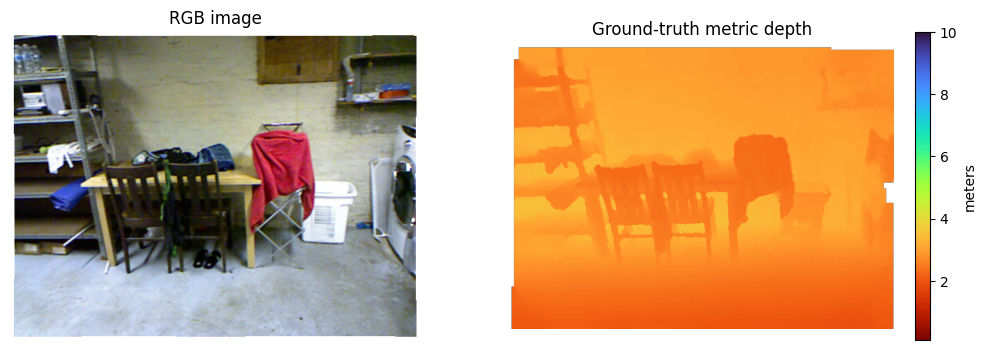

RGB size (width, height): (640, 480)
Depth array shape: (480, 640)
Valid-pixel fraction: 97.04%
Valid depth minimum (m): 1.9021320343017578
Valid depth maximum (m): 3.566497564315796


In [5]:
def decode_image_value(value):
    '''Decode a PIL image, a datasets decode(False) dictionary, or a local path.'''
    if isinstance(value, Image.Image):
        return value.copy()

    if isinstance(value, dict):
        image_bytes = value.get("bytes")
        image_path = value.get("path")
        if image_bytes is not None:
            with Image.open(io.BytesIO(image_bytes)) as opened:
                return opened.copy()
        if image_path:
            with Image.open(image_path) as opened:
                return opened.copy()
        raise ValueError("The image dictionary contains neither bytes nor a path.")

    if isinstance(value, (str, Path)):
        with Image.open(value) as opened:
            return opened.copy()

    raise TypeError(f"Unsupported image value type: {type(value)!r}")


def read_rgb_depth(record, depth_scale=1.0):
    '''Return a PIL RGB image and a float32 depth array in meters.'''
    if isinstance(record, dict):
        rgb = decode_image_value(record["image"])
        depth = decode_image_value(record["depth_map"])
    else:
        rgb = decode_image_value(record[0])
        depth = decode_image_value(record[1])

    rgb = ImageOps.exif_transpose(rgb).convert("RGB")
    depth_np = np.asarray(depth).astype(np.float32)
    if depth_np.ndim == 3:
        depth_np = depth_np[..., 0]
    depth_np = depth_np / float(depth_scale)
    return rgb, depth_np

rgb0, depth0 = read_rgb_depth(train_records[0], depth_scale)
valid0 = np.isfinite(depth0) & (depth0 > MIN_DEPTH_M) & (depth0 < MAX_DEPTH_M)
valid_fraction0 = float(valid0.mean())

if valid0.sum() == 0:
    raise RuntimeError("The first sample has no valid depth pixels. Check the unit and scale.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(rgb0)
axes[0].set_title("RGB image")
depth_plot = axes[1].imshow(
    np.where(valid0, depth0, np.nan),
    cmap="turbo_r",
    vmin=MIN_DEPTH_M,
    vmax=MAX_DEPTH_M,
)
axes[1].set_title("Ground-truth metric depth")
for axis in axes:
    axis.axis("off")
fig.colorbar(depth_plot, ax=axes[1], fraction=0.046, label="meters")
plt.show()

print("RGB size (width, height):", rgb0.size)
print("Depth array shape:", depth0.shape)
print(f"Valid-pixel fraction: {valid_fraction0:.2%}")
print("Valid depth minimum (m):", float(depth0[valid0].min()))
print("Valid depth maximum (m):", float(depth0[valid0].max()))

## 14. Paired preprocessing and augmentation

A geometric transformation must be applied consistently to all spatially aligned arrays:

```text
RGB image + depth map + validity mask
```

For example, if the RGB image is horizontally flipped but the depth map is not, each input pixel receives the wrong target.

Photometric augmentation is different. Brightness, contrast, saturation, and hue affect only the RGB appearance; they must not change the physical depth.

This implementation performs:

1. conversion to tensors;
2. valid-mask creation before division;
3. fixed-size resizing;
4. synchronized random horizontal flipping during training;
5. RGB-only color jitter during training;
6. ImageNet mean and standard-deviation normalization;
7. inverse-depth target construction.

Depth and the validity mask use nearest-neighbor resizing in this low-memory teaching pipeline. This avoids blending an invalid zero depth into a valid neighbor. A more advanced project can implement mask-aware bilinear resizing.

In [6]:
class RGBDepthDataset(Dataset):
    def __init__(self, records, train, depth_scale=1.0):
        self.records = records
        self.train = train
        self.depth_scale = depth_scale
        self.color_jitter = ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.15,
            hue=0.03,
        )

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        rgb, depth_np = read_rgb_depth(self.records[index], self.depth_scale)

        rgb_t = TF.to_tensor(rgb)
        depth_t = torch.from_numpy(depth_np).unsqueeze(0)
        mask_t = (
            torch.isfinite(depth_t)
            & (depth_t > MIN_DEPTH_M)
            & (depth_t < MAX_DEPTH_M)
        )
        depth_t = torch.where(mask_t, depth_t, torch.zeros_like(depth_t))

        rgb_t = TF.resize(rgb_t, [IMG_SIZE, IMG_SIZE], antialias=True)
        depth_t = F.interpolate(
            depth_t.unsqueeze(0),
            size=(IMG_SIZE, IMG_SIZE),
            mode="nearest",
        ).squeeze(0)
        mask_t = F.interpolate(
            mask_t.float().unsqueeze(0),
            size=(IMG_SIZE, IMG_SIZE),
            mode="nearest",
        ).squeeze(0).bool()

        if self.train and random.random() < 0.5:
            rgb_t = torch.flip(rgb_t, dims=[2])
            depth_t = torch.flip(depth_t, dims=[2])
            mask_t = torch.flip(mask_t, dims=[2])

        if self.train:
            rgb_t = self.color_jitter(rgb_t).clamp(0, 1)

        rgb_t = TF.normalize(
            rgb_t,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )
        inv_depth_t = torch.where(
            mask_t,
            1.0 / depth_t.clamp_min(MIN_DEPTH_M),
            torch.zeros_like(depth_t),
        )

        return {
            "image": rgb_t,
            "depth": depth_t,
            "inv_depth": inv_depth_t,
            "mask": mask_t,
        }


train_dataset = RGBDepthDataset(train_records, train=True, depth_scale=depth_scale)
val_dataset = RGBDepthDataset(val_records, train=False, depth_scale=depth_scale)

worker_options = {}
if NUM_WORKERS > 0:
    worker_options = {
        "persistent_workers": True,
        "prefetch_factor": PREFETCH_FACTOR,
    }

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    **worker_options,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    **worker_options,
)

In [7]:
sample_batch = next(iter(train_loader))
print("Batch tensor shapes")
for key, value in sample_batch.items():
    print(f"{key:10s}: shape={tuple(value.shape)}, dtype={value.dtype}")

assert sample_batch["image"].shape == (BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE)
assert sample_batch["depth"].shape == (BATCH_SIZE, 1, IMG_SIZE, IMG_SIZE)
assert sample_batch["inv_depth"].shape == (BATCH_SIZE, 1, IMG_SIZE, IMG_SIZE)
assert sample_batch["mask"].dtype == torch.bool
print("Shape and dtype checks passed.")

Batch tensor shapes
image     : shape=(2, 3, 336, 336), dtype=torch.float32
depth     : shape=(2, 1, 336, 336), dtype=torch.float32
inv_depth : shape=(2, 1, 336, 336), dtype=torch.float32
mask      : shape=(2, 1, 336, 336), dtype=torch.bool
Shape and dtype checks passed.


## 15. Load the pretrained model and freeze the encoder

The model identifier is constructed as:

```text
LiheYoung/depth_anything_vits14
```

When `FREEZE_ENCODER=True`:

- DINOv2 weights keep their pretrained values;
- only the DPT depth head receives optimizer updates;
- the run uses less memory;
- a tiny dataset is less likely to destroy the encoder's general representation.

This is transfer learning. Full fine-tuning can later be attempted with `FREEZE_ENCODER=False`, more data, and a lower encoder learning rate. A lower encoder rate reduces the risk of **catastrophic forgetting**, where aggressive updates erase valuable pretrained knowledge.

In [8]:
MODEL_ID = f"LiheYoung/depth_anything_{ENCODER}14"
model = DepthAnything.from_pretrained(MODEL_ID).to(DEVICE)

for parameter in model.pretrained.parameters():
    parameter.requires_grad = not FREEZE_ENCODER
for parameter in model.depth_head.parameters():
    parameter.requires_grad = True

total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)

print("Model identifier:", MODEL_ID)
print(f"Total parameters: {total_parameters / 1e6:.2f} M")
print(f"Trainable parameters: {trainable_parameters / 1e6:.2f} M")
print(f"Trainable fraction: {trainable_parameters / total_parameters:.2%}")

xFormers not available
xFormers not available


Model identifier: LiheYoung/depth_anything_vits14
Total parameters: 24.79 M
Trainable parameters: 2.73 M
Trainable fraction: 11.01%


## 16. Inspect intermediate transformer features

This cell is a direct bridge between the architecture explanation and the running model. With a `336×336` input and `14×14` patches, each selected layer should expose `576` patch tokens.

Expected ViT-S patch-token shape:

```text
[1, 196, 384]
```

The four tensors have the same token count but come from different depths in the transformer. DPT converts them to a multi-resolution feature pyramid.

In [9]:
model.eval()
dummy_image = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

with torch.inference_mode():
    intermediate_features = model.pretrained.get_intermediate_layers(
        dummy_image,
        4,
        return_class_token=True,
    )

patch_grid = IMG_SIZE // 14
print(
    "Expected patch grid:",
    patch_grid,
    "x",
    patch_grid,
    "=",
    patch_grid * patch_grid,
    "tokens",
)
for index, (patch_tokens, class_token) in enumerate(intermediate_features, start=1):
    print(
        f"Feature {index}: patch tokens={tuple(patch_tokens.shape)}, "
        f"class token={tuple(class_token.shape)}"
    )

del dummy_image, intermediate_features
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

Expected patch grid: 24 x 24 = 576 tokens
Feature 1: patch tokens=(1, 576, 384), class token=(1, 384)
Feature 2: patch tokens=(1, 576, 384), class token=(1, 384)
Feature 3: patch tokens=(1, 576, 384), class token=(1, 384)
Feature 4: patch tokens=(1, 576, 384), class token=(1, 384)


## 17. Validity masks and the inverse-depth target

Sensors do not provide valid depth everywhere. Invalid values may include:

- zero or negative depth;
- `NaN` or infinity;
- missing readings on glass or mirrors;
- values beyond the useful sensor range.

Consider:

\[
D =
\begin{bmatrix}
1 & 0\\
4 & \operatorname{NaN}
\end{bmatrix}
\]

The validity mask is:

\[
M =
\begin{bmatrix}
1 & 0\\
1 & 0
\end{bmatrix}
\]

Losses and metrics are computed only where `M=True`. Masking must happen before inverse depth is computed; otherwise `1/0` creates infinities.

## 18. Why scale-and-shift alignment is required

Suppose the inverse-depth target is:

\[
T=
\begin{bmatrix}
1 & 0.5\\
0.25 & 0.125
\end{bmatrix}
\]

and the relative model predicts:

\[
P=
\begin{bmatrix}
5 & 4\\
3.5 & 3.25
\end{bmatrix}
\]

The values look different, but:

\[
P=2T+3
\]

The relative structure is perfect. To compare the prediction with the target, solve for a scale `a` and shift `b`:

\[
P_{aligned}=aP+b
\]

Here, `a=0.5` and `b=-1.5`, so `P_aligned=T`.

For each image, the code minimizes the masked least-squares objective:

\[
\min_{a,b}\sum_i M_i(aP_i+b-T_i)^2
\]

This creates a fair comparison for relative depth. It also explains a crucial limitation: metrics computed after per-image ground-truth alignment measure relative structure, not independent metric calibration.

## 19. Loss function

The total loss has two components.

### 19.1 Masked data loss

After alignment:

\[
L_{data}=\frac{1}{N}\sum_i M_i\left|P_{aligned,i}-T_i\right|
\]

This encourages correct inverse-depth values up to the allowed global scale and shift.

### 19.2 Gradient loss

A per-pixel loss alone can produce overly smooth boundaries. Horizontal and vertical finite differences are therefore compared:

\[
G_x(i,j)=D(i,j+1)-D(i,j)
\]

\[
G_y(i,j)=D(i+1,j)-D(i,j)
\]

Only adjacent pixel pairs for which both pixels are valid are included. The final objective is:

\[
L=L_{data}+\lambda L_{gradient}
\]

with `lambda = 0.5` by default.

In [10]:
def align_scale_and_shift(prediction, target, mask, eps=1e-6):
    '''Align each predicted map to its target with masked least squares.'''
    if prediction.ndim == 3:
        prediction = prediction.unsqueeze(1)
    if target.ndim == 3:
        target = target.unsqueeze(1)
    if mask.ndim == 3:
        mask = mask.unsqueeze(1)

    mask_f = mask.float()
    reduce_dims = (1, 2, 3)

    a00 = (mask_f * prediction * prediction).sum(reduce_dims)
    a01 = (mask_f * prediction).sum(reduce_dims)
    a11 = mask_f.sum(reduce_dims)
    b0 = (mask_f * prediction * target).sum(reduce_dims)
    b1 = (mask_f * target).sum(reduce_dims)

    determinant = a00 * a11 - a01 * a01
    valid_system = determinant.abs() > eps
    safe_determinant = torch.where(
        valid_system,
        determinant,
        torch.ones_like(determinant),
    )

    scale = (a11 * b0 - a01 * b1) / safe_determinant
    shift = (-a01 * b0 + a00 * b1) / safe_determinant
    scale = torch.where(valid_system, scale, torch.ones_like(scale))
    shift = torch.where(valid_system, shift, torch.zeros_like(shift))

    aligned = (
        scale[:, None, None, None] * prediction
        + shift[:, None, None, None]
    )
    return aligned, scale, shift


def masked_mean(values, mask):
    mask_f = mask.float()
    return (values * mask_f).sum() / mask_f.sum().clamp_min(1.0)


def scale_shift_invariant_loss(
    prediction,
    target_inv_depth,
    mask,
    gradient_weight=GRADIENT_LOSS_WEIGHT,
):
    aligned, _, _ = align_scale_and_shift(prediction, target_inv_depth, mask)
    data_loss = masked_mean((aligned - target_inv_depth).abs(), mask)

    valid_x = mask[:, :, :, 1:] & mask[:, :, :, :-1]
    valid_y = mask[:, :, 1:, :] & mask[:, :, :-1, :]

    pred_dx = aligned[:, :, :, 1:] - aligned[:, :, :, :-1]
    pred_dy = aligned[:, :, 1:, :] - aligned[:, :, :-1, :]
    target_dx = target_inv_depth[:, :, :, 1:] - target_inv_depth[:, :, :, :-1]
    target_dy = target_inv_depth[:, :, 1:, :] - target_inv_depth[:, :, :-1, :]

    grad_x_loss = masked_mean((pred_dx - target_dx).abs(), valid_x)
    grad_y_loss = masked_mean((pred_dy - target_dy).abs(), valid_y)
    gradient_loss = grad_x_loss + grad_y_loss

    total_loss = data_loss + gradient_weight * gradient_loss
    return total_loss, data_loss.detach(), gradient_loss.detach()

In [11]:
# A small numerical check for the alignment function.
target_example = torch.tensor([[[[1.0, 0.5], [0.25, 0.125]]]])
prediction_example = 2.0 * target_example + 3.0
mask_example = torch.ones_like(target_example, dtype=torch.bool)

aligned_example, scale_example, shift_example = align_scale_and_shift(
    prediction_example,
    target_example,
    mask_example,
)

print("Recovered scale:", float(scale_example[0]))
print("Recovered shift:", float(shift_example[0]))
print("Maximum alignment error:", float((aligned_example - target_example).abs().max()))
assert torch.allclose(aligned_example, target_example, atol=1e-5)

Recovered scale: 0.5
Recovered shift: -1.5
Maximum alignment error: 0.0


## 20. Evaluation metrics

After inverse-depth alignment, predictions are converted back to metric depth for reporting.

### Absolute Relative Error

\[
\operatorname{AbsRel}=\frac{1}{N}\sum_i
\frac{|D_i^{pred}-D_i^{gt}|}{D_i^{gt}}
\]

Lower is better. It expresses error relative to the true distance.

### Root Mean Squared Error

\[
\operatorname{RMSE}=\sqrt{\frac{1}{N}\sum_i
(D_i^{pred}-D_i^{gt})^2}
\]

Lower is better. Large errors receive stronger penalties. Here the unit is meters.

### Delta-one accuracy

\[
\delta_1=\frac{1}{N}\sum_i
\mathbf{1}\left[
\max\left(\frac{D_i^{pred}}{D_i^{gt}},
\frac{D_i^{gt}}{D_i^{pred}}\right)<1.25
\right]
\]

Higher is better. A value of `0.80` means that 80% of valid pixels satisfy the threshold.

This notebook aggregates all valid pixels across the small validation subset. Serious benchmark reporting should use the official dataset crop, split, resizing, and aggregation protocol.

In [12]:
@torch.inference_mode()
def evaluate(model, loader):
    model.eval()
    absrel_sum = 0.0
    squared_error_sum = 0.0
    delta1_count = 0.0
    pixel_count = 0

    for batch in loader:
        image = batch["image"].to(DEVICE, non_blocking=True)
        depth = batch["depth"].to(DEVICE, non_blocking=True)
        target_inv = batch["inv_depth"].to(DEVICE, non_blocking=True)
        mask = batch["mask"].to(DEVICE, non_blocking=True)

        pred_inv = model(image)
        aligned_inv, _, _ = align_scale_and_shift(pred_inv, target_inv, mask)
        aligned_inv = aligned_inv.clamp(
            min=1.0 / MAX_DEPTH_M,
            max=1.0 / MIN_DEPTH_M,
        )
        pred_depth = 1.0 / aligned_inv

        valid_prediction = torch.isfinite(pred_depth) & (pred_depth > 0)
        valid = mask & valid_prediction
        gt = depth[valid]
        pd = pred_depth[valid]
        count = gt.numel()
        if count == 0:
            continue

        absrel_sum += ((pd - gt).abs() / gt.clamp_min(1e-6)).sum().item()
        squared_error_sum += ((pd - gt) ** 2).sum().item()
        ratio = torch.maximum(
            pd / gt.clamp_min(1e-6),
            gt / pd.clamp_min(1e-6),
        )
        delta1_count += (ratio < 1.25).sum().item()
        pixel_count += count

    return {
        "AbsRel": absrel_sum / max(pixel_count, 1),
        "RMSE": (squared_error_sum / max(pixel_count, 1)) ** 0.5,
        "delta1": delta1_count / max(pixel_count, 1),
    }


@torch.inference_mode()
def predict_gt_aligned_depth(model, batch):
    '''Produce metric depth only for visualization against available ground truth.'''
    model.eval()
    image = batch["image"].to(DEVICE)
    target_inv = batch["inv_depth"].to(DEVICE)
    mask = batch["mask"].to(DEVICE)

    pred_inv = model(image)
    aligned_inv, _, _ = align_scale_and_shift(pred_inv, target_inv, mask)
    aligned_inv = aligned_inv.clamp(
        min=1.0 / MAX_DEPTH_M,
        max=1.0 / MIN_DEPTH_M,
    )
    return (1.0 / aligned_inv).cpu()

## 21. Establish a pretrained baseline

A baseline answers: **How well does the released model perform before this experiment changes any weight?**

Without a baseline, a lower training loss does not prove that fine-tuning improved validation performance. The same validation samples and alignment procedure are used before and after training.

Because the subset contains only sixteen images, the metrics can vary substantially with the selected samples. Treat them as a pipeline check.

In [13]:
demo_batch = next(iter(val_loader))
baseline_depth_visualization = predict_gt_aligned_depth(model, demo_batch)[0, 0].numpy()
baseline_metrics = evaluate(model, val_loader)

print("Pretrained baseline metrics")
for metric_name, metric_value in baseline_metrics.items():
    unit = " m" if metric_name == "RMSE" else ""
    print(f"{metric_name:7s}: {metric_value:.4f}{unit}")

Pretrained baseline metrics
AbsRel : 0.0684
RMSE   : 0.3664 m
delta1 : 0.9499


## 22. One-epoch optimization strategy

A single epoch needs enough optimizer updates without exceeding 6 GiB VRAM. The notebook separates **micro-batch size** from **effective batch size**:

\[
B_{effective}=B_{micro}\times N_{accumulation}=2\times2=4
\]

Two micro-batches are backpropagated before one AdamW update. The gradients are divided by the actual number of micro-batches in the accumulation window, so the final partial window is also correct.

The head learning rate is `2e-4`. A short step-based schedule uses approximately 10% of updates for linear warm-up and then cosine decay. This is more useful for one epoch than an epoch-level scheduler that changes only after the entire run.

The encoder remains frozen, so only the DPT head is optimized. AMP reduces memory. Gradient clipping limits unstable updates. Fused AdamW is requested when the installed PyTorch build and CUDA device support it, with a safe fallback to standard AdamW.

With 128 samples, micro-batch size 2, and accumulation 2:

```text
64 forward/backward micro-steps
32 optimizer updates
exactly 1 epoch
```

In [14]:
head_parameters = [
    parameter for parameter in model.depth_head.parameters() if parameter.requires_grad
]
encoder_parameters = [
    parameter for parameter in model.pretrained.parameters() if parameter.requires_grad
]

parameter_groups = [{"params": head_parameters, "lr": HEAD_LR}]
if encoder_parameters:
    parameter_groups.append({"params": encoder_parameters, "lr": ENCODER_LR})

adamw_options = {"weight_decay": WEIGHT_DECAY}
if DEVICE.type == "cuda":
    adamw_options["fused"] = True
try:
    optimizer = torch.optim.AdamW(parameter_groups, **adamw_options)
    print("Fused AdamW enabled:", bool(adamw_options.get("fused", False)))
except (TypeError, RuntimeError):
    adamw_options.pop("fused", None)
    optimizer = torch.optim.AdamW(parameter_groups, **adamw_options)
    print("Using standard AdamW.")

updates_per_epoch = math.ceil(len(train_loader) / ACCUMULATION_STEPS)
total_update_steps = max(EPOCHS * updates_per_epoch, 1)
warmup_steps = max(1, int(round(0.10 * total_update_steps)))


def one_epoch_lr_multiplier(step):
    if step < warmup_steps:
        return float(step + 1) / float(warmup_steps)
    decay_steps = max(total_update_steps - warmup_steps, 1)
    progress = min((step - warmup_steps) / decay_steps, 1.0)
    return 0.5 * (1.0 + math.cos(math.pi * progress))


scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=one_epoch_lr_multiplier,
)
use_amp = DEVICE.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

history = {
    "train_loss": [],
    "train_data_loss": [],
    "train_gradient_loss": [],
    "val_absrel": [],
    "val_rmse": [],
    "val_delta1": [],
    "last_learning_rate": [],
}
best_rmse = float("inf")
CHECKPOINT_PATH = OUTPUT_DIR / "depth_anything_v1_gtx1660super_1epoch.pt"

print("Micro-batches per epoch:", len(train_loader))
print("Optimizer updates per epoch:", updates_per_epoch)
print("Warm-up updates:", warmup_steps)
print("Total optimizer updates:", total_update_steps)

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    print(
        "CUDA memory before training: "
        f"{torch.cuda.memory_allocated() / 1024**2:.1f} MiB allocated"
    )

Fused AdamW enabled: True
Micro-batches per epoch: 64
Optimizer updates per epoch: 32
Warm-up updates: 3
Total optimizer updates: 32
CUDA memory before training: 103.5 MiB allocated


In [15]:
optimizer.zero_grad(set_to_none=True)
global_update_step = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    if FREEZE_ENCODER:
        # The frozen encoder does not need training-mode behavior.
        model.pretrained.eval()

    running_total_loss = 0.0
    running_data_loss = 0.0
    running_gradient_loss = 0.0

    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    number_of_micro_batches = len(train_loader)

    for micro_batch_index, batch in enumerate(progress):
        image = batch["image"].to(DEVICE, non_blocking=True)
        target_inv = batch["inv_depth"].to(DEVICE, non_blocking=True)
        mask = batch["mask"].to(DEVICE, non_blocking=True)

        accumulation_group_start = (
            micro_batch_index // ACCUMULATION_STEPS
        ) * ACCUMULATION_STEPS
        accumulation_group_size = min(
            ACCUMULATION_STEPS,
            number_of_micro_batches - accumulation_group_start,
        )

        amp_context = (
            torch.autocast(device_type="cuda", dtype=torch.float16)
            if use_amp
            else nullcontext()
        )

        try:
            with amp_context:
                pred_inv = model(image)
                loss, data_loss, gradient_loss = scale_shift_invariant_loss(
                    pred_inv,
                    target_inv,
                    mask,
                )
                backward_loss = loss / accumulation_group_size
        except torch.OutOfMemoryError as error:
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()
            raise RuntimeError(
                "The GTX 1660 SUPER ran out of memory. Restart the kernel and "
                "first set BATCH_SIZE=1. If necessary, also set IMG_SIZE=280. "
                "Keep FREEZE_ENCODER=True."
            ) from error

        scaler.scale(backward_loss).backward()

        is_accumulation_boundary = (
            (micro_batch_index + 1) % ACCUMULATION_STEPS == 0
            or (micro_batch_index + 1) == number_of_micro_batches
        )
        if is_accumulation_boundary:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [
                    parameter
                    for parameter in model.parameters()
                    if parameter.requires_grad
                ],
                max_norm=1.0,
            )
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            global_update_step += 1

        running_total_loss += loss.item()
        running_data_loss += data_loss.item()
        running_gradient_loss += gradient_loss.item()
        progress.set_postfix(
            loss=f"{loss.item():.4f}",
            update=global_update_step,
        )

    number_of_batches = max(number_of_micro_batches, 1)
    epoch_total_loss = running_total_loss / number_of_batches
    epoch_data_loss = running_data_loss / number_of_batches
    epoch_gradient_loss = running_gradient_loss / number_of_batches
    metrics = evaluate(model, val_loader)

    history["train_loss"].append(epoch_total_loss)
    history["train_data_loss"].append(epoch_data_loss)
    history["train_gradient_loss"].append(epoch_gradient_loss)
    history["val_absrel"].append(metrics["AbsRel"])
    history["val_rmse"].append(metrics["RMSE"])
    history["val_delta1"].append(metrics["delta1"])
    history["last_learning_rate"].append(optimizer.param_groups[0]["lr"])

    print(
        f"Epoch {epoch}: total_loss={epoch_total_loss:.4f} | "
        f"data_loss={epoch_data_loss:.4f} | "
        f"gradient_loss={epoch_gradient_loss:.4f} | "
        f"AbsRel={metrics['AbsRel']:.4f} | "
        f"RMSE={metrics['RMSE']:.4f} m | "
        f"delta1={metrics['delta1']:.4f}"
    )

    if metrics["RMSE"] < best_rmse:
        best_rmse = metrics["RMSE"]
        trainable_state = {
            name: parameter.detach().cpu()
            for name, parameter in model.named_parameters()
            if parameter.requires_grad
        }
        torch.save(
            {
                "trainable_state": trainable_state,
                "encoder": ENCODER,
                "img_size": IMG_SIZE,
                "data_source": DATA_SOURCE,
                "best_rmse": best_rmse,
                "configuration": {
                    "epochs": EPOCHS,
                    "micro_batch_size": BATCH_SIZE,
                    "accumulation_steps": ACCUMULATION_STEPS,
                    "effective_batch_size": BATCH_SIZE * ACCUMULATION_STEPS,
                    "freeze_encoder": FREEZE_ENCODER,
                    "head_lr": HEAD_LR,
                    "encoder_lr": ENCODER_LR,
                    "gradient_loss_weight": GRADIENT_LOSS_WEIGHT,
                    "optimizer_updates": global_update_step,
                },
            },
            CHECKPOINT_PATH,
        )

if DEVICE.type == "cuda":
    print(
        "Peak CUDA memory during training: "
        f"{torch.cuda.max_memory_allocated() / 1024**3:.2f} GiB"
    )
print("Completed epochs:", EPOCHS)
print("Optimizer updates:", global_update_step)
print("Best checkpoint:", CHECKPOINT_PATH)

Epoch 1/1: 100%|██████████| 64/64 [00:17<00:00,  3.64it/s, loss=0.0188, update=32]


Epoch 1: total_loss=0.0411 | data_loss=0.0372 | gradient_loss=0.0078 | AbsRel=0.0695 | RMSE=0.3465 m | delta1=0.9469
Peak CUDA memory during training: 2.26 GiB
Completed epochs: 1
Optimizer updates: 32
Best checkpoint: /home/amin/Desktop/depthanythingv1/Depth-Anything/local_runs_gtx1660super_1epoch/depth_anything_v1_gtx1660super_1epoch.pt


## 23. Plot the one-epoch history

A one-epoch experiment contains only one point per curve. The plotting code is included so that the same notebook continues to work if you later increase `EPOCHS`.

Interpret the curves together:

- decreasing training loss and improving validation metrics suggest useful learning;
- decreasing training loss with worsening validation metrics suggests overfitting;
- validation metrics can still be noisy with only sixteen images;
- delta-one should rise, while AbsRel and RMSE should fall.

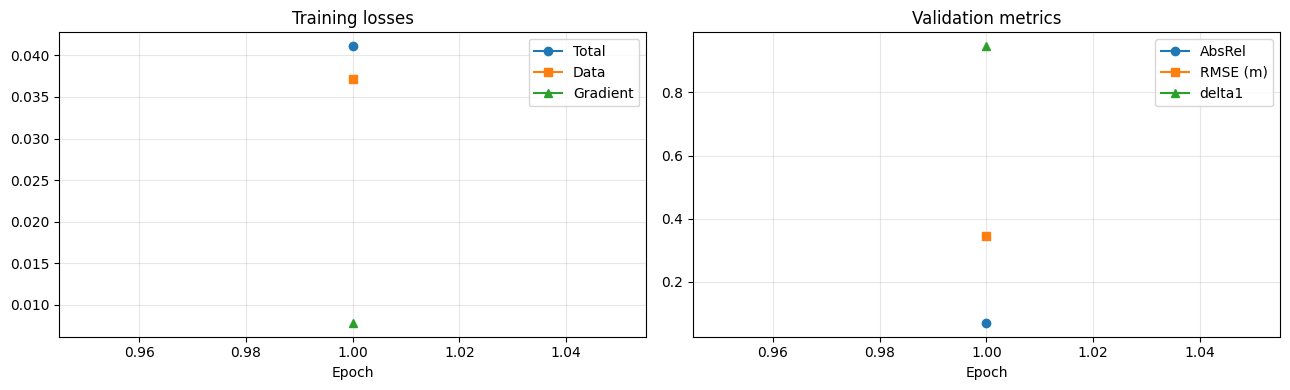

In [16]:
epoch_axis = np.arange(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epoch_axis, history["train_loss"], marker="o", label="Total")
axes[0].plot(epoch_axis, history["train_data_loss"], marker="s", label="Data")
axes[0].plot(
    epoch_axis,
    history["train_gradient_loss"],
    marker="^",
    label="Gradient",
)
axes[0].set_title("Training losses")
axes[0].set_xlabel("Epoch")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epoch_axis, history["val_absrel"], marker="o", label="AbsRel")
axes[1].plot(epoch_axis, history["val_rmse"], marker="s", label="RMSE (m)")
axes[1].plot(epoch_axis, history["val_delta1"], marker="^", label="delta1")
axes[1].set_title("Validation metrics")
axes[1].set_xlabel("Epoch")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 24. Reload the best checkpoint and compare before versus after

The last epoch is not necessarily the best epoch. The training loop stores a checkpoint whenever validation RMSE improves. Only parameters that were trainable are saved; the released pretrained weights are already present in the model object.

The four-panel visualization shows:

1. ground-truth metric depth;
2. pretrained prediction after ground-truth alignment;
3. fine-tuned prediction after ground-truth alignment;
4. absolute metric error.

Both predictions use ground truth for scale-and-shift alignment, so these panels compare relative geometric structure rather than standalone metric calibration.

Metric comparison
Metric   |     Before |      After | Direction
--------------------------------------------------
AbsRel   |     0.0684 |     0.0695 |     lower
RMSE     |     0.3664 |     0.3465 |     lower
delta1   |     0.9499 |     0.9469 |    higher


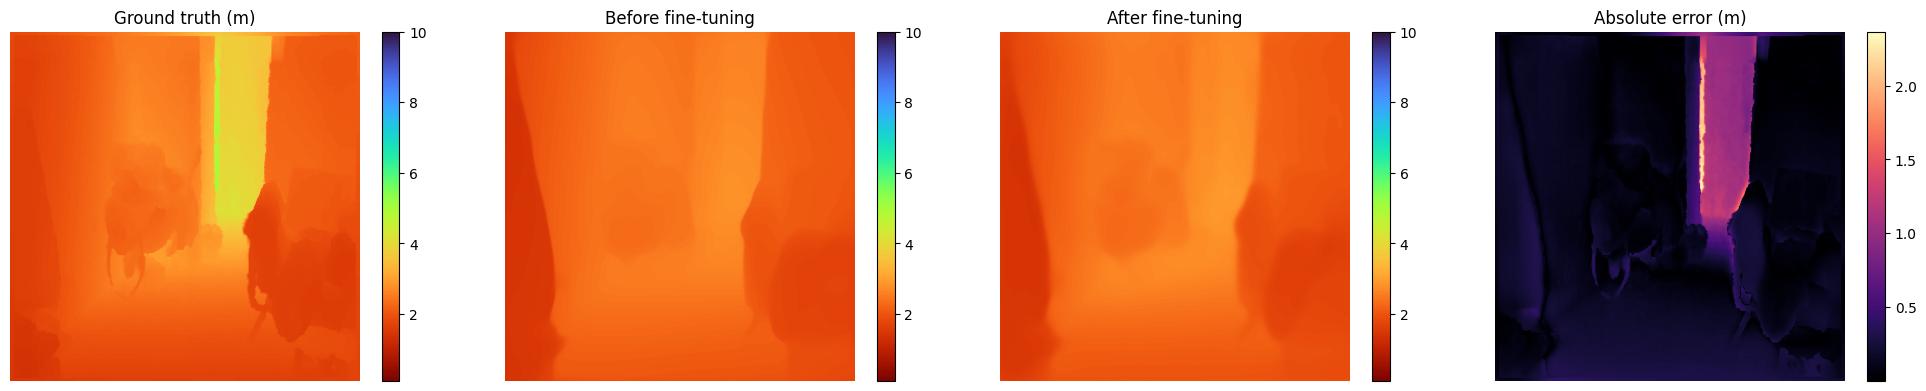

In [17]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")
missing_keys, unexpected_keys = model.load_state_dict(
    checkpoint["trainable_state"],
    strict=False,
)
model.to(DEVICE).eval()

fine_tuned_metrics = evaluate(model, val_loader)
fine_tuned_depth_visualization = predict_gt_aligned_depth(model, demo_batch)[0, 0].numpy()
gt_depth_visualization = demo_batch["depth"][0, 0].numpy()
valid_visualization = demo_batch["mask"][0, 0].numpy()

print("Metric comparison")
print(f"{'Metric':8s} | {'Before':>10s} | {'After':>10s} | {'Direction':>9s}")
print("-" * 50)
for metric_name in ["AbsRel", "RMSE", "delta1"]:
    direction = "lower" if metric_name in {"AbsRel", "RMSE"} else "higher"
    print(
        f"{metric_name:8s} | {baseline_metrics[metric_name]:10.4f} | "
        f"{fine_tuned_metrics[metric_name]:10.4f} | {direction:>9s}"
    )

absolute_error = np.abs(
    fine_tuned_depth_visualization - gt_depth_visualization
)
absolute_error[~valid_visualization] = np.nan
gt_to_show = np.where(valid_visualization, gt_depth_visualization, np.nan)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
arrays = [
    gt_to_show,
    baseline_depth_visualization,
    fine_tuned_depth_visualization,
    absolute_error,
]
titles = [
    "Ground truth (m)",
    "Before fine-tuning",
    "After fine-tuning",
    "Absolute error (m)",
]
colormaps = ["turbo_r", "turbo_r", "turbo_r", "magma"]

for index, (axis, array, title, colormap) in enumerate(
    zip(axes, arrays, titles, colormaps)
):
    if index < 3:
        image_artist = axis.imshow(
            array,
            cmap=colormap,
            vmin=MIN_DEPTH_M,
            vmax=MAX_DEPTH_M,
        )
    else:
        image_artist = axis.imshow(array, cmap=colormap)
    axis.set_title(title)
    axis.axis("off")
    fig.colorbar(image_artist, ax=axis, fraction=0.046)

plt.tight_layout()
plt.show()

## 25. Inference on a new RGB image without ground truth

New-image inference contains no target, mask, loss, optimizer, or scale-and-shift alignment.

```text
New RGB image
    ↓
Resize, tensor conversion, normalization
    ↓
DINOv2 + DPT forward pass
    ↓
Relative inverse-depth map
    ↓
Resize to the original image dimensions
    ↓
Percentile normalization for visualization
```

The raw model values are retained in `raw_relative_inverse_depth`. The display map uses the 2nd and 98th percentiles to reduce the effect of outliers:

\[
V=\operatorname{clip}\left(
\frac{P-P_2}{P_{98}-P_2},0,1
\right)
\]

This normalization changes only the visualization. It does not convert the prediction to meters.

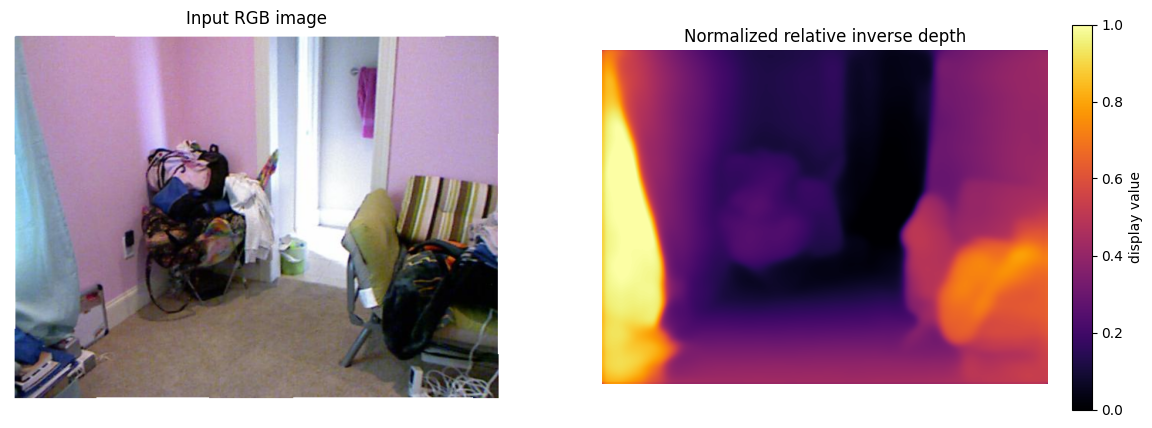

Raw relative map shape: (480, 640)
Raw relative minimum: 1.1062132120132446
Raw relative maximum: 20.416305541992188


In [18]:
def preprocess_rgb_only(pil_image):
    rgb = ImageOps.exif_transpose(pil_image).convert("RGB")
    tensor = TF.to_tensor(rgb)
    tensor = TF.resize(tensor, [IMG_SIZE, IMG_SIZE], antialias=True)
    tensor = TF.normalize(
        tensor,
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    )
    return rgb, tensor.unsqueeze(0)


@torch.inference_mode()
def predict_relative_inverse_depth(pil_image):
    model.eval()
    rgb, tensor = preprocess_rgb_only(pil_image)
    prediction = model(tensor.to(DEVICE))
    prediction = F.interpolate(
        prediction.unsqueeze(1),
        size=(rgb.height, rgb.width),
        mode="bilinear",
        align_corners=False,
    )[0, 0]

    raw_prediction = prediction.cpu().numpy()
    low, high = np.percentile(raw_prediction, [2, 98])
    normalized = np.clip(
        (raw_prediction - low) / max(high - low, 1e-6),
        0,
        1,
    )
    return rgb, raw_prediction, normalized


# Enter an absolute image path, or leave None to reuse one validation RGB image.
TEST_IMAGE_PATH = None  # Example: "/home/amin/Pictures/my_photo.jpg"

if TEST_IMAGE_PATH:
    test_image = Image.open(TEST_IMAGE_PATH)
else:
    test_image, _ = read_rgb_depth(val_records[0], depth_scale)

rgb_test, raw_relative_inverse_depth, relative_visualization = (
    predict_relative_inverse_depth(test_image)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(rgb_test)
axes[0].set_title("Input RGB image")
relative_artist = axes[1].imshow(relative_visualization, cmap="inferno")
axes[1].set_title("Normalized relative inverse depth")
for axis in axes:
    axis.axis("off")
fig.colorbar(relative_artist, ax=axes[1], fraction=0.046, label="display value")
plt.show()

print("Raw relative map shape:", raw_relative_inverse_depth.shape)
print("Raw relative minimum:", float(raw_relative_inverse_depth.min()))
print("Raw relative maximum:", float(raw_relative_inverse_depth.max()))

In [19]:
OUTPUT_DEPTH_PNG = OUTPUT_DIR / "predicted_relative_inverse_depth.png"
OUTPUT_DEPTH_NPY = OUTPUT_DIR / "predicted_relative_inverse_depth_raw.npy"

Image.fromarray(
    (relative_visualization * 255).astype(np.uint8)
).save(OUTPUT_DEPTH_PNG)
np.save(OUTPUT_DEPTH_NPY, raw_relative_inverse_depth.astype(np.float32))

print("Visualization PNG:", OUTPUT_DEPTH_PNG)
print("Raw float32 array:", OUTPUT_DEPTH_NPY)
print("Fine-tuned checkpoint:", CHECKPOINT_PATH)
print("All outputs are stored in:", OUTPUT_DIR)

Visualization PNG: /home/amin/Desktop/depthanythingv1/Depth-Anything/local_runs_gtx1660super_1epoch/predicted_relative_inverse_depth.png
Raw float32 array: /home/amin/Desktop/depthanythingv1/Depth-Anything/local_runs_gtx1660super_1epoch/predicted_relative_inverse_depth_raw.npy
Fine-tuned checkpoint: /home/amin/Desktop/depthanythingv1/Depth-Anything/local_runs_gtx1660super_1epoch/depth_anything_v1_gtx1660super_1epoch.pt
All outputs are stored in: /home/amin/Desktop/depthanythingv1/Depth-Anything/local_runs_gtx1660super_1epoch


## 26. How to interpret the visualization correctly

The model output in this notebook is treated as relative inverse depth:

```text
larger raw value  → usually nearer
smaller raw value → usually farther
```

The final color depends on the colormap. In `inferno`, larger display values are usually brighter. In a reversed colormap, the visual order would be reversed. Never interpret color without checking all four questions:

1. Is the array depth or inverse depth?
2. Is the colormap normal or reversed?
3. Is the displayed array raw or normalized?
4. Are the values relative or metric?

The saved PNG is an 8-bit visualization. The saved `.npy` file preserves the raw floating-point relative prediction and is the appropriate file for later numerical processing.

To obtain meters on unseen images, use a metric-depth model or supply additional calibration information, such as known object dimensions, a known-distance reference, camera geometry with a suitable calibration procedure, stereo, or an active depth sensor.

## 27. One sample from beginning to end

### Training path

```text
1. Read RGB and metric depth.
2. Mark valid depths between 0.1 m and 10 m.
3. Resize RGB, depth, and mask to 336×336.
4. Apply synchronized horizontal flip when selected.
5. Apply RGB-only color jitter.
6. Normalize RGB with ImageNet statistics.
7. Convert metric depth to inverse depth.
8. Split RGB into 14×14 patches: 576 patch tokens.
9. Process tokens with DINOv2 ViT-S.
10. Extract four intermediate representations.
11. Reassemble tokens into DPT feature maps.
12. Construct and fuse the multi-scale pyramid.
13. Predict a 336×336 relative inverse-depth map.
14. Align prediction to the target with scale and shift.
15. Compute masked data and gradient losses.
16. Backpropagate through trainable DPT parameters.
17. Update parameters with AdamW.
```

### Validation path

The preprocessing and forward pass are similar, but no gradient is stored and no weight is updated. Metrics are computed after ground-truth alignment.

### New-image inference path

Only the RGB forward path remains. There is no target, alignment, loss, backward pass, optimizer step, or metric evaluation.

## 28. Common failure cases in monocular depth

Even a strong model may struggle with:

- mirrors, glass, water, and polished surfaces;
- darkness, saturation, motion blur, or sensor noise;
- very thin structures such as cables and chair legs;
- repeated patterns and textureless walls;
- unusual camera viewpoints;
- objects whose size is ambiguous;
- scenes far outside the training distribution;
- boundaries lost by low-resolution resizing;
- indoor-to-outdoor or synthetic-to-real domain shift.

A visually smooth depth map is not automatically accurate. Always inspect quantitative metrics when ground truth exists, and inspect failure regions at full resolution.

## 29. GTX 1660 SUPER troubleshooting guide

| Symptom | Likely cause | Recommended action |
|---|---|---|
| `torch.cuda.is_available()` is `False` | Wrong Jupyter kernel, driver, or CPU-only PyTorch | Select `Python (depthanything)`, check `nvidia-smi`, reinstall the cu126 wheel |
| Architecture warning for `sm_75` | PyTorch wheel does not contain Turing kernels | Install a CUDA-enabled wheel that includes compute capability 7.5 |
| CUDA out of memory | 6 GiB is partly occupied or the card differs from the usual model | Restart kernel; set batch `1`; if needed use `IMG_SIZE=280` |
| GPU utilization is low | Data loading or CPU preprocessing is the bottleneck | Keep two workers, pinned memory, prefetching, and persistent workers |
| Desktop becomes slow | The display server and training share the same GPU | Close GPU-heavy applications and avoid excessive batch/resolution |
| Model or dataset download fails | Network or cache problem | Verify access, then retry; custom-folder mode remains available |
| Loss becomes `NaN` | Invalid depth values or incorrect unit scale | Inspect depth min/max, valid fraction, masks, and `CUSTOM_DEPTH_SCALE` |
| Fine-tuning is worse than baseline | One epoch, small subset, or overfitting | Increase data before epochs; keep encoder frozen; validate by scene |

Monitor the run in another terminal:

```bash
watch -n 2 nvidia-smi
```

Peak memory is controlled mainly by model size, input resolution, and micro-batch size. Gradient accumulation increases the effective batch size without storing two accumulation windows simultaneously.

## 30. Experimental limitations and a path to a serious project

This notebook makes several deliberate simplifications:

- only one epoch and a very small subset;
- square resizing instead of aspect-ratio-preserving preprocessing;
- nearest-neighbor depth resizing;
- no official NYU benchmark crop or scene-list enforcement;
- no separate held-out test set;
- per-image ground-truth alignment for relative evaluation;
- no independent metric-depth calibration.

For a serious experiment:

1. split data by scene, not by neighboring video frame;
2. create train, validation, and untouched test partitions;
3. preserve aspect ratio and pad/crop to a multiple of `14`;
4. use more samples and epochs with early stopping;
5. log experiment configurations and random seeds;
6. use the benchmark's official crop and evaluation protocol;
7. compare frozen-head training with staged encoder unfreezing;
8. report confidence intervals or variation across multiple seeds;
9. evaluate cross-domain data separately;
10. use the official metric-depth path when meters are the product requirement.

## 31. Suggested classroom flow

### Part 1 — Build intuition

Show a single room image and ask students which monocular cues indicate near and far regions. Compare monocular inference with stereo triangulation and LiDAR measurement.

### Part 2 — Follow tensor shapes

Calculate the patch count manually and run the intermediate-feature cell. Ask why all transformer layers initially share the same patch-grid resolution.

### Part 3 — Explain encoder and decoder roles

Use the phrase: **DINOv2 provides semantic and contextual understanding; DPT converts that understanding into a dense spatial prediction.**

### Part 4 — Demonstrate ambiguity

Compare raw relative values with metric ground truth. Use the numerical alignment example to show why the structure can be right even when numbers differ.

### Part 5 — Run the experiment

Record the pretrained baseline, fine-tune only the head for one epoch, reload the best checkpoint, and discuss whether the change is meaningful given only sixteen validation images.

### Part 6 — Analyze failure cases

Ask students to identify errors around object boundaries, reflective regions, thin structures, and domain-shifted scenes.

## 32. Exercises

### Introductory

1. For input sizes `280`, `308`, `336`, and `392`, calculate the patch-grid size and token count.
2. Disable `ColorJitter` and compare the one-epoch loss.
3. Run inference on three personal images and label at least two failure regions in each.
4. Explain why a bright pixel in a colored depth map does not always mean "near."

### Intermediate

1. Compare `GRADIENT_LOSS_WEIGHT` values `0`, `0.25`, `0.5`, and `1.0`.
2. Increase the dataset to `256` training samples and `32` validation samples, then train for five epochs.
3. Log elapsed time and peak CUDA memory for input sizes `280`, `336`, and `392`.
4. Replace nearest-neighbor depth resizing with mask-aware bilinear resizing.
5. Compare random image splitting with scene-level splitting and explain leakage.

### Advanced

1. Preserve aspect ratio, then pad to a multiple of `14`; remove padding after inference.
2. Add SILog and multi-scale gradient losses and compare them with the current objective.
3. Unfreeze the last encoder blocks gradually instead of unfreezing the entire encoder at once.
4. Run the official metric-depth pipeline and compare metric output with ground-truth-aligned relative output.
5. Train on indoor NYU data and evaluate on outdoor images to quantify domain shift.
6. Convert a calibrated metric depth map to a colored point cloud using camera intrinsics.

### Key discussion question

Why is the final transformer feature alone insufficient for precise dense depth, and why does DPT use four intermediate representations?

## 33. Expected output files

After a successful full run, the directory `Depth-Anything/local_runs_gtx1660super_1epoch/` contains:

| File | Purpose |
|---|---|
| `depth_anything_v1_gtx1660super_1epoch.pt` | Best trainable checkpoint based on validation RMSE |
| `predicted_relative_inverse_depth.png` | 8-bit visualization for viewing or slides |
| `predicted_relative_inverse_depth_raw.npy` | Raw float32 relative prediction for numerical work |

Keep the checkpoint together with its configuration. A checkpoint trained with one encoder type or input procedure should not be silently loaded under incompatible assumptions.

## 34. Primary references

- Depth Anything V1 repository: https://github.com/LiheYoung/Depth-Anything
- Repository snapshot used here: commit `1d03336771fe09c5398ffdd211441e33941a97dc`
- Paper: https://arxiv.org/abs/2401.10891
- Official metric-depth directory: https://github.com/LiheYoung/Depth-Anything/tree/main/metric_depth
- NYU Depth V2 dataset card: https://huggingface.co/datasets/sayakpaul/nyu_depth_v2
- Official PyTorch previous-version commands: https://pytorch.org/get-started/previous-versions/
- NVIDIA CUDA release notes: https://docs.nvidia.com/cuda/cuda-toolkit-release-notes/index.html
- Newer Depth Anything V2 repository: https://github.com/DepthAnything/Depth-Anything-V2

This notebook intentionally teaches **Depth Anything V1** to match the requested repository. For a new production project, evaluate V2 and metric-depth alternatives separately instead of assuming that V1 is the best current deployment choice.